In [109]:
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from src.data.dataloader import generate_data

# интегрирование
from scipy.integrate import simpson


### Загрузка данных


In [110]:
np.random.seed(42)

In [111]:
X, y, amplitudes = generate_data(
    number_of_samples=5000,
    amp_range=(2, 15),
    length=200,
    noise_std=1
)

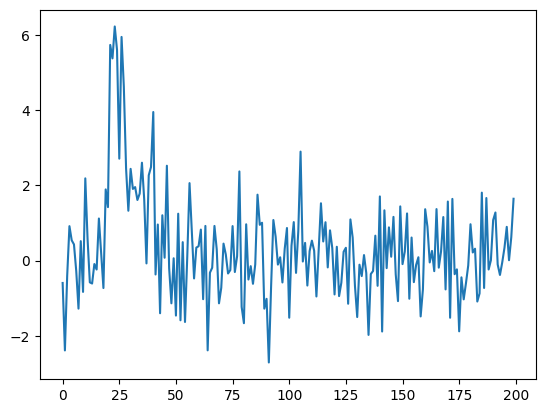

In [112]:
plt.plot(X[0])

### создаю датафрейм для x и будущих признаков




In [113]:
#для признаков
data_fetures = {
    'amplitudes': amplitudes,
    'target': y
}
feature_df = pd.DataFrame(data_fetures)
feature_df.rename_axis('pulse_id')

#для импульсов

X_df = pd.DataFrame(X)
X_df.rename_axis('pulse_id')
print("таблицы созданы")

таблицы созданы


**Считаю полный заряд**

In [114]:
feature_df['whole_energy'] = [simpson(y=X_df.iloc[idx], dx=1) for idx in X_df.index]

**Нормировка сигнала**

In [115]:
X_df = X_df.apply(lambda row: row / np.max(row), axis=1)

### Центрирую данные




In [116]:
from sklearn.preprocessing import StandardScaler

In [117]:
scaler = StandardScaler()
X_df_scaled = scaler.fit_transform(X_df)

### Понижаю размерность с помощью PCA

In [118]:
from sklearn.decomposition import PCA

In [119]:
pca = PCA(n_components=5)

In [120]:
pca_component = pca.fit_transform(X_df)


In [121]:
pca_df = pd.DataFrame(pca_component)

In [122]:
rename_dict = {}
for column in pca_df:
    rename_dict[column] = f'PCA_{column + 1}'

pca_final_df = pca_df.rename(columns=rename_dict)

In [123]:
feature_df_with_pca = feature_df.join(pca_final_df)

In [124]:
feature_df_with_pca

,amplitudes,target,whole_energy,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5
0,5.981860,1.0,68.801927,-0.282984,0.358594,-0.036089,0.147869,-0.074950
1,14.232004,1.0,173.682366,-0.439972,0.141889,-0.102951,-0.094577,-0.011810
2,10.926873,1.0,127.009125,-0.368976,0.306580,0.035585,0.134718,0.105279
3,9.006232,1.0,114.245385,-0.406448,0.126625,-0.206519,-0.042298,-0.067661
4,3.386331,1.0,35.578120,-0.535083,0.166611,-0.385537,0.269280,-0.011033
...,...,...,...,...,...,...,...,...
4995,13.410338,0.0,289.648690,0.513820,0.033967,-0.033428,-0.014258,0.018556
4996,3.004193,0.0,67.844556,-0.218805,-0.728474,0.039908,0.148554,-0.100139
4997,5.391627,0.0,134.380299,0.329730,-0.199538,0.045662,0.235904,0.005350
4998,12.171445,0.0,241.242235,0.615744,0.170232,-0.071101,-0.013184,-0.030361


### Отрисовка кластеров через метод главных компонент

[]

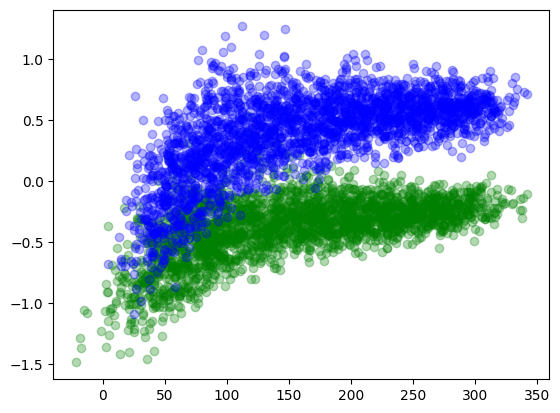

In [132]:
gamma_mask = feature_df_with_pca['target'] == 1
neutron_mask = feature_df_with_pca['target'] == 0

factor = np.max(feature_df['whole_energy'][neutron_mask]) / np.max(feature_df['whole_energy'][gamma_mask])

plt.scatter(feature_df_with_pca['whole_energy'][gamma_mask] * factor, feature_df_with_pca['PCA_1'][gamma_mask], c='green', alpha=0.3)
plt.scatter(feature_df_with_pca['whole_energy'][neutron_mask], feature_df_with_pca['PCA_1'][neutron_mask], c='blue', alpha=0.3)
plt.plot()

[]

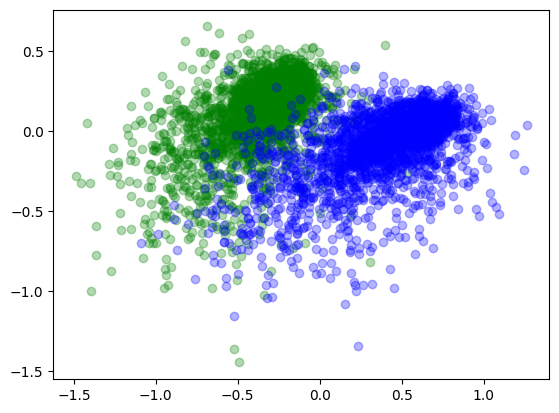

In [133]:
plt.scatter(feature_df_with_pca['PCA_1'][gamma_mask], feature_df_with_pca['PCA_2'][gamma_mask], c='green', alpha=0.3)
plt.scatter(feature_df_with_pca['PCA_1'][neutron_mask], feature_df_with_pca['PCA_2'][neutron_mask], c='blue', alpha=0.3)
plt.plot()


--- ЗАПУСК GMM КЛАСТЕРИЗАЦИИ ---
Инвертируем метки кластеров для совпадения с target...
Точность (Accuracy) разделения без учителя: 92.54%

Отчет по классам (Classification Report):
              precision    recall  f1-score   support

 Neutron (0)       0.99      0.86      0.92      2500
   Gamma (1)       0.87      0.99      0.93      2500

    accuracy                           0.93      5000
   macro avg       0.93      0.93      0.93      5000
weighted avg       0.93      0.93      0.93      5000



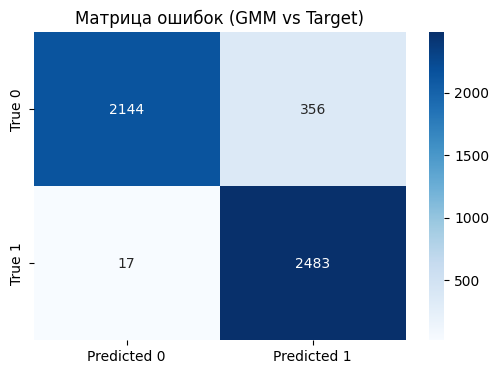

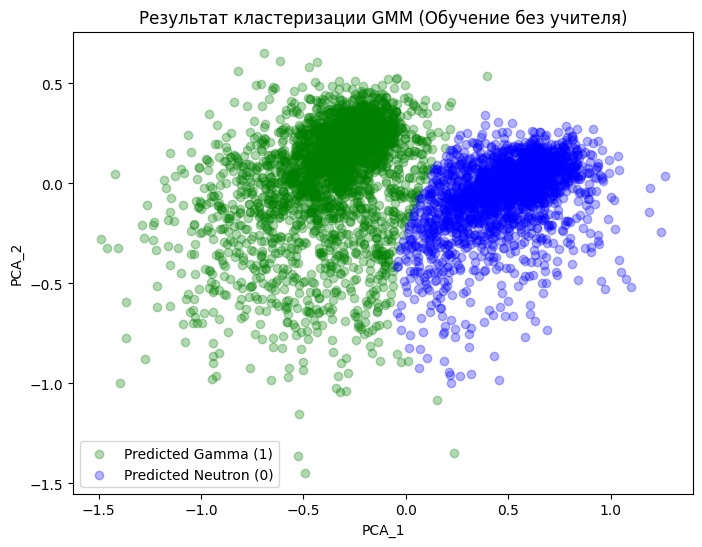

In [135]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns # Для красивой матрицы ошибок

print("\n--- ЗАПУСК GMM КЛАСТЕРИЗАЦИИ ---")

# 1. Выбираем признаки, на которых будем обучать модель. 
# Лучше всего работают первые две компоненты (они содержат максимум информации о форме)
X_gmm = feature_df_with_pca[['PCA_1', 'PCA_2']].values

# 2. Инициализируем и обучаем GMM
# n_components=2, так как мы знаем, что ищем два типа частиц (нейтроны и гамму)
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
feature_df_with_pca['gmm_cluster'] = gmm.fit_predict(X_gmm)

# 3. Сопоставление меток (Label Matching)
# Проверяем, совпали ли индексы кластеров GMM с нашим target
acc = accuracy_score(feature_df_with_pca['target'], feature_df_with_pca['gmm_cluster'])

# Если точность меньше 50%, значит модель "перепутала" индексы (0 стал 1, а 1 стал 0)
if acc < 0.5:
    print("Инвертируем метки кластеров для совпадения с target...")
    feature_df_with_pca['gmm_cluster'] = 1 - feature_df_with_pca['gmm_cluster']
    acc = accuracy_score(feature_df_with_pca['target'], feature_df_with_pca['gmm_cluster'])

# 4. Вывод метрик
print(f"Точность (Accuracy) разделения без учителя: {acc * 100:.2f}%\n")
print("Отчет по классам (Classification Report):")
print(classification_report(feature_df_with_pca['target'], feature_df_with_pca['gmm_cluster'], target_names=['Neutron (0)', 'Gamma (1)']))

# 5. Отрисовка Матрицы ошибок (Confusion Matrix)
cm = confusion_matrix(feature_df_with_pca['target'], feature_df_with_pca['gmm_cluster'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.title('Матрица ошибок (GMM vs Target)')
plt.show()

# 6. Отрисовка того, как GMM разделила кластеры
gmm_gamma_mask = feature_df_with_pca['gmm_cluster'] == 1
gmm_neutron_mask = feature_df_with_pca['gmm_cluster'] == 0

plt.figure(figsize=(8, 6))
# Строим график предсказаний GMM в тех же цветах для наглядности
plt.scatter(feature_df_with_pca['PCA_1'][gmm_gamma_mask], feature_df_with_pca['PCA_2'][gmm_gamma_mask], c='green', alpha=0.3, label='Predicted Gamma (1)')
plt.scatter(feature_df_with_pca['PCA_1'][gmm_neutron_mask], feature_df_with_pca['PCA_2'][gmm_neutron_mask], c='blue', alpha=0.3, label='Predicted Neutron (0)')

# Рисуем центры кластеров, которые нашла модель
centers = gmm.means_
#plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, marker='X', label='GMM Centers')

plt.title("Результат кластеризации GMM (Обучение без учителя)")
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
plt.legend()
plt.show()

In [128]:
import umap

# 1. Инициализируем UMAP
# n_neighbors: баланс между локальной и глобальной структурой (15-30 — норма)
# min_dist: насколько плотно точки прилегают друг к другу (0.1 — стандарт)
reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=-1)

# Обучаем на масштабированных данных
umap_components = reducer.fit_transform(X_df_scaled)

# Создаем DataFrame
umap_df = pd.DataFrame(umap_components, columns=['UMAP_1', 'UMAP_2', 'UMAP_3'])
feature_df_with_umap = feature_df.join(umap_df)

print("UMAP успешно применен. Размерность снижена до 3.")

d:\PROGA\neutron_vs_gamma\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP успешно применен. Размерность снижена до 3.


[]

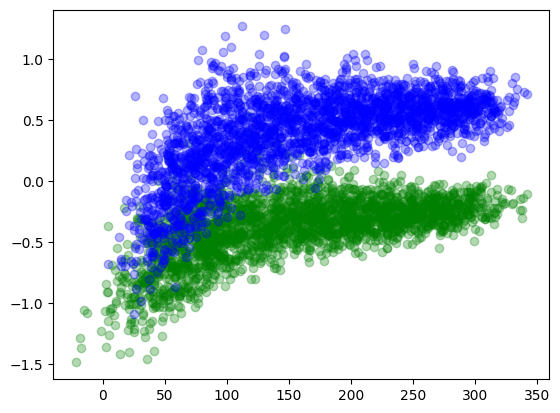

In [129]:
plt.scatter(feature_df_with_pca['whole_energy'][gamma_mask] * factor, feature_df_with_pca['PCA_1'][gamma_mask], c='green', alpha=0.3)
plt.scatter(feature_df_with_pca['whole_energy'][neutron_mask], feature_df_with_pca['PCA_1'][neutron_mask], c='blue', alpha=0.3)
plt.plot()

[]

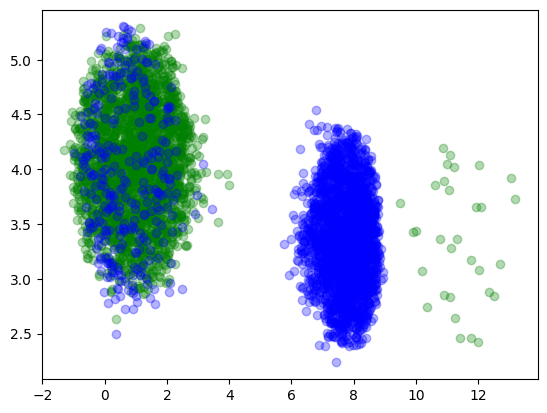

In [130]:
plt.scatter(feature_df_with_umap['UMAP_1'][gamma_mask] * factor, feature_df_with_umap['UMAP_2'][gamma_mask], c='green', alpha=0.3)
plt.scatter(feature_df_with_umap['UMAP_1'][neutron_mask], feature_df_with_umap['UMAP_2'][neutron_mask], c='blue', alpha=0.3)
plt.plot()


--- ЗАПУСК GMM КЛАСТЕРИЗАЦИИ (UMAP) ---
Точность (Accuracy) с UMAP: 93.16%
              precision    recall  f1-score   support

         0.0       0.99      0.88      0.93      2500
         1.0       0.89      0.99      0.94      2500

    accuracy                           0.93      5000
   macro avg       0.94      0.93      0.93      5000
weighted avg       0.94      0.93      0.93      5000



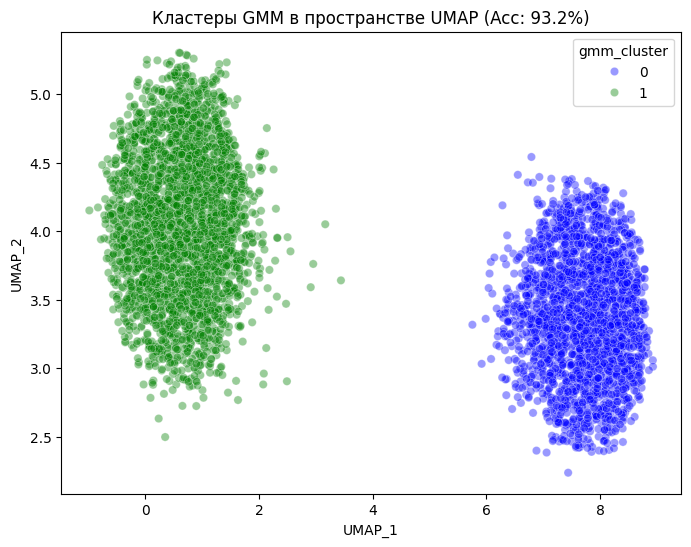

In [131]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("\n--- ЗАПУСК GMM КЛАСТЕРИЗАЦИИ (UMAP) ---")

# Используем первые 2 компоненты UMAP
X_gmm_umap = feature_df_with_umap[['UMAP_1', 'UMAP_2']].values

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
feature_df_with_umap['gmm_cluster'] = gmm.fit_predict(X_gmm_umap)

# Маппинг меток
acc = accuracy_score(feature_df_with_umap['target'], feature_df_with_umap['gmm_cluster'])
if acc < 0.5:
    feature_df_with_umap['gmm_cluster'] = 1 - feature_df_with_umap['gmm_cluster']
    acc = accuracy_score(feature_df_with_umap['target'], feature_df_with_umap['gmm_cluster'])

print(f"Точность (Accuracy) с UMAP: {acc * 100:.2f}%")
print(classification_report(feature_df_with_umap['target'], feature_df_with_umap['gmm_cluster']))

# Визуализация разделения
plt.figure(figsize=(8, 6))
sns.scatterplot(data=feature_df_with_umap, x='UMAP_1', y='UMAP_2', 
                hue='gmm_cluster', palette={0: 'blue', 1: 'green'}, alpha=0.4)
plt.title(f"Кластеры GMM в пространстве UMAP (Acc: {acc*100:.1f}%)")
plt.show()


--- ЗАПУСК K-MEANS КЛАСТЕРИЗАЦИИ (БЕЗ УЧИТЕЛЯ) ---
Инвертируем метки кластеров для совпадения с target...
Точность (Accuracy) разделения без учителя: 92.30%

Отчет по классам (Classification Report):
              precision    recall  f1-score   support

 Neutron (0)       0.99      0.86      0.92      2500
   Gamma (1)       0.87      0.99      0.93      2500

    accuracy                           0.92      5000
   macro avg       0.93      0.92      0.92      5000
weighted avg       0.93      0.92      0.92      5000



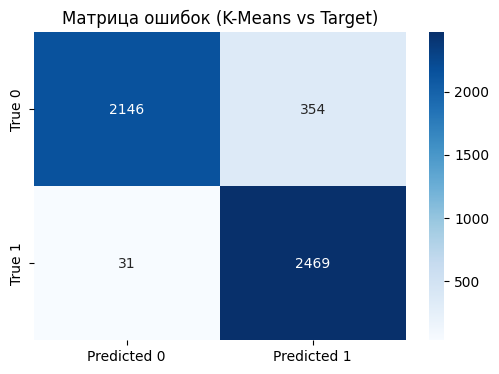

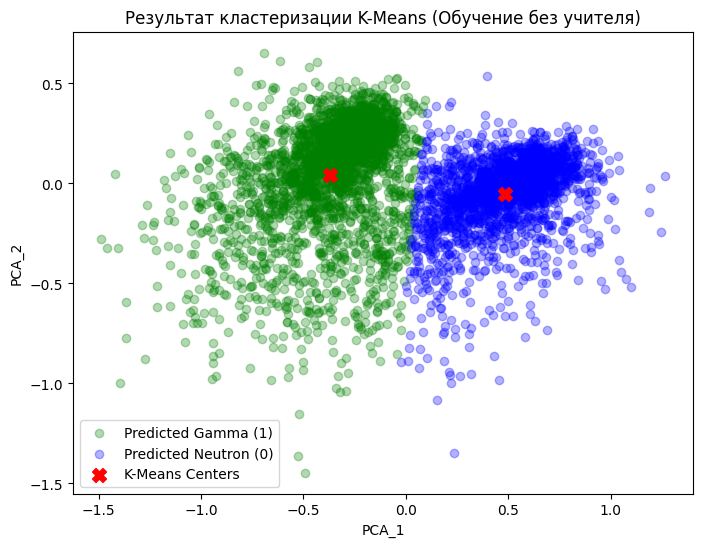

In [134]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- ЗАПУСК K-MEANS КЛАСТЕРИЗАЦИИ (БЕЗ УЧИТЕЛЯ) ---")

# 1. Выбираем признаки, на которых будем обучать модель. 
X_kmeans = feature_df_with_pca[['PCA_1', 'PCA_2']].values

# 2. Инициализируем и обучаем K-Means
# n_clusters=2, так как ищем два типа частиц (нейтроны и гамму)
# n_init=10 добавляем, чтобы убрать системное предупреждение sklearn в новых версиях
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
feature_df_with_pca['kmeans_cluster'] = kmeans.fit_predict(X_kmeans)

# 3. Сопоставление меток (Label Matching)
# Проверяем, совпали ли индексы кластеров K-Means с нашим target
acc = accuracy_score(feature_df_with_pca['target'], feature_df_with_pca['kmeans_cluster'])

# Если точность меньше 50%, значит модель "перепутала" индексы
if acc < 0.5:
    print("Инвертируем метки кластеров для совпадения с target...")
    feature_df_with_pca['kmeans_cluster'] = 1 - feature_df_with_pca['kmeans_cluster']
    # Пересчитываем точность после инверсии
    acc = accuracy_score(feature_df_with_pca['target'], feature_df_with_pca['kmeans_cluster'])

# 4. Вывод метрик
print(f"Точность (Accuracy) разделения без учителя: {acc * 100:.2f}%\n")
print("Отчет по классам (Classification Report):")
print(classification_report(feature_df_with_pca['target'], feature_df_with_pca['kmeans_cluster'], target_names=['Neutron (0)', 'Gamma (1)']))

# 5. Отрисовка Матрицы ошибок (Confusion Matrix)
cm = confusion_matrix(feature_df_with_pca['target'], feature_df_with_pca['kmeans_cluster'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.title('Матрица ошибок (K-Means vs Target)')
plt.show()

# 6. Отрисовка того, как K-Means разделил кластеры
kmeans_gamma_mask = feature_df_with_pca['kmeans_cluster'] == 1
kmeans_neutron_mask = feature_df_with_pca['kmeans_cluster'] == 0

plt.figure(figsize=(8, 6))
# Строим график предсказаний
plt.scatter(feature_df_with_pca['PCA_1'][kmeans_gamma_mask], feature_df_with_pca['PCA_2'][kmeans_gamma_mask], c='green', alpha=0.3, label='Predicted Gamma (1)')
plt.scatter(feature_df_with_pca['PCA_1'][kmeans_neutron_mask], feature_df_with_pca['PCA_2'][kmeans_neutron_mask], c='blue', alpha=0.3, label='Predicted Neutron (0)')

# Рисуем центры кластеров, которые нашла модель.
# Обратите внимание: у K-Means это свойство называется cluster_centers_ (а не means_ как у GMM)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, marker='X', label='K-Means Centers')

plt.title("Результат кластеризации K-Means (Обучение без учителя)")
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
plt.legend()
plt.show()